In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
import h5py
from collections import Counter
import scipy.sparse as sp
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.patheffects as path_effects
import yaml
import time
from itertools import combinations
import gget
from scipy.stats import zscore
import matplotlib.patches as patches

from pycirclize import Circos
from pycirclize.parser import Matrix
from pycirclize.utils import ColorCycler

from matplotlib_venn import venn3_unweighted
from matplotlib_venn import venn2_unweighted
import matplotlib.colors as mcolors
import matplotlib.patheffects as path_effects
import matplotlib.ticker as mtick

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc

# import scvi
# from scvi.external import SysVI

import cupy as cp
import cudf
import rmm
from rmm.allocators.cupy import rmm_cupy_allocator

from cuml.manifold.umap import simplicial_set_embedding
from scanpy.tools._utils import get_init_pos_from_paga 
from cuml.manifold.umap import find_ab_params

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

sc.settings.verbosity = 2

# Load in data

In [2]:
%%time 
# === Load and filter GTF ===
gpath = "/scratch/indikar_root/indikar1/shared_data/HYB/resources/refdata-gex-GRCh38-2024-A_genes.csv.gz"

gtf = pd.read_csv(gpath)

exons = gtf[gtf['Feature'] == 'exon']
print(f"{exons.shape=}")
exons.head()

exons.shape=(1586950, 27)
CPU times: user 7.69 s, sys: 1.31 s, total: 9 s
Wall time: 9.09 s


,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,gene_version,...,transcript_name,transcript_support_level,havana_transcript,exon_number,exon_id,exon_version,hgnc_id,havana_gene,protein_id,ccdsid
2,GL000009.2,ENSEMBL,exon,56139,58376,.,-,.,ENSG00000278704,1,...,ENST00000618686,NaN,NaN,1.0,ENSE00003753029,1.0,NaN,NaN,ENSP00000484918.1,NaN
10,GL000194.1,ENSEMBL,exon,114985,115018,.,-,.,ENSG00000277400,1,...,ENST00000613230,1.0,NaN,1.0,ENSE00002299440,2.0,NaN,NaN,ENSP00000483280.1,NaN
11,GL000194.1,ENSEMBL,exon,112791,112850,.,-,.,ENSG00000277400,1,...,ENST00000613230,1.0,NaN,2.0,ENSE00003739295,1.0,NaN,NaN,ENSP00000483280.1,NaN
12,GL000194.1,ENSEMBL,exon,53589,55676,.,-,.,ENSG00000277400,1,...,ENST00000613230,1.0,NaN,3.0,ENSE00003723764,1.0,NaN,NaN,ENSP00000483280.1,NaN
22,GL000194.1,ENSEMBL,exon,114985,115055,.,-,.,ENSG00000274847,1,...,MAFIP-201,1.0,NaN,1.0,ENSE00003736481,1.0,HGNC:31102,NaN,ENSP00000478910.1,NaN


In [3]:
fpath = "../resources/isoform_map.csv.gz"

idf = pd.read_csv(fpath)
print(f"{idf.shape=}")

idf['uniprot'] = np.where(idf['UniProtKB/TrEMBL ID'].isna(), idf['UniProtKB/Swiss-Prot ID'], idf['UniProtKB/TrEMBL ID'])

transcript_2_uniprot = dict(zip(idf['Transcript name'].values, idf['uniprot'].values))

print(f"N unique uniprot IDs: {idf['uniprot'].nunique()}")
idf.head()

idf.shape=(110149, 11)
N unique uniprot IDs: 73747


,Gene stable ID,Gene stable ID version,Transcript stable ID,Transcript stable ID version,Protein stable ID,Protein stable ID version,Transcript length (including UTRs and CDS),Transcript name,Gene name,UniProtKB/Swiss-Prot ID,UniProtKB/TrEMBL ID,uniprot
0,ENSG00000198888,ENSG00000198888.2,ENST00000361390,ENST00000361390.2,ENSP00000354687,ENSP00000354687.2,956,MT-ND1-201,MT-ND1,P03886,U5Z754,U5Z754
1,ENSG00000198763,ENSG00000198763.3,ENST00000361453,ENST00000361453.3,ENSP00000355046,ENSP00000355046.4,1042,MT-ND2-201,MT-ND2,P03891,Q7GXY9,Q7GXY9
2,ENSG00000198804,ENSG00000198804.2,ENST00000361624,ENST00000361624.2,ENSP00000354499,ENSP00000354499.2,1542,MT-CO1-201,MT-CO1,P00395,U5YWV7,U5YWV7
3,ENSG00000198712,ENSG00000198712.1,ENST00000361739,ENST00000361739.1,ENSP00000354876,ENSP00000354876.1,684,MT-CO2-201,MT-CO2,P00403,U5Z487,U5Z487
4,ENSG00000228253,ENSG00000228253.1,ENST00000361851,ENST00000361851.1,ENSP00000355265,ENSP00000355265.1,207,MT-ATP8-201,MT-ATP8,P03928,U5YV54,U5YV54


In [4]:
upath = "/scratch/indikar_root/indikar1/jrcwycy/hsc_temp/HUMAN_9606_idmapping_selected.tab.gz"

columns = [
    'UniProtKB-AC',
    'UniProtKB-ID',
    'GeneID (EntrezGene)',
    'RefSeq',
    'GI',
    'PDB',
    'GO',
    'UniRef100',
    'UniRef90',
    'UniRef50',
    'UniParc',
    'PIR',
    'NCBI-taxon',
    'MIM',
    'UniGene',
    'PubMed',
    'EMBL',
    'EMBL-CDS',
    'Ensembl',
    'Ensembl_TRS',
    'Ensembl_PRO',
    'Additional PubMed',
]

udf = pd.read_csv(
    upath, 
    sep='\t',
    header=None,
    low_memory=False,
    names=columns,
)

keep_columns = [
    'UniProtKB-AC',
    'UniProtKB-ID',
    # 'Ensembl',
    'Ensembl_TRS',
]

udf = udf[keep_columns]
udf = udf.assign(Ensembl_TRS=udf['Ensembl_TRS'].str.split(';')).explode('Ensembl_TRS')
udf['transcript_id'] = udf['Ensembl_TRS'].apply(lambda x: str(x).split(".")[0])
udf = udf.rename(columns={'UniProtKB-AC': 'uniprot'})

transcript_map = dict(zip(udf['transcript_id'].values, udf['uniprot'].values))

print(f"N unique uniprot IDs: {udf['uniprot'].nunique()}")
udf.head()

N unique uniprot IDs: 205003


,uniprot,UniProtKB-ID,Ensembl_TRS,transcript_id
0,P31946,1433B_HUMAN,ENST00000353703.9,ENST00000353703
0,P31946,1433B_HUMAN,ENST00000372839.7,ENST00000372839
1,P62258,1433E_HUMAN,ENST00000264335.13,ENST00000264335
1,P62258,1433E_HUMAN,ENST00000571732.5,ENST00000571732
1,P62258,1433E_HUMAN,ENST00000616643.3,ENST00000616643


In [5]:
gtf_sub = gtf[['transcript_id', 'transcript_name']].drop_duplicates()
gtf_sub = gtf_sub.dropna()
print(gtf_sub.shape)
gtf_sub.head()

udf1 = pd.merge(udf, gtf_sub, how='left', on='transcript_id')
print(udf1.shape)

udf1 = udf1.dropna(subset='transcript_name')

print(udf1.shape)
print(f"N unique uniprot IDs: {udf1['uniprot'].nunique()}")


transcript_map = dict(zip(udf1['transcript_name'].values, udf1['uniprot'].values))

udf1.head()

(226005, 2)
(246523, 5)
(78415, 5)
N unique uniprot IDs: 78415


,uniprot,UniProtKB-ID,Ensembl_TRS,transcript_id,transcript_name
0,P31946,1433B_HUMAN,ENST00000353703.9,ENST00000353703,YWHAB-201
2,P62258,1433E_HUMAN,ENST00000264335.13,ENST00000264335,YWHAE-201
6,Q04917,1433F_HUMAN,ENST00000248975.6,ENST00000248975,YWHAH-201
7,P61981,1433G_HUMAN,ENST00000307630.5,ENST00000307630,YWHAG-201
8,P31947,1433S_HUMAN,ENST00000339276.6,ENST00000339276,SFN-201


In [6]:
fpath = "../resources/allTFs_hg38.txt"
tf_list = [x.strip() for x in open(fpath)]
tf_list[:10]

['ZNF354C',
 'KLF12',
 'ZNF143',
 'ZIC2',
 'ZNF274',
 'SP2',
 'ZBTB7A',
 'BCL6B',
 'ZBTB49',
 'ZIC1']

In [7]:
%%time
fpath = "/scratch/indikar_root/indikar1/shared_data/hematokytos/new_processed/isoforms.h5ad"
adata = sc.read_h5ad(fpath)

adata.var['uniprot'] = adata.var.index.map(transcript_2_uniprot)

adata

CPU times: user 1.26 s, sys: 476 ms, total: 1.73 s
Wall time: 3.49 s


AnnData object with n_obs × n_vars = 20754 × 113335
    obs: 'dataset', 'source', 'label', 'cluster_all', 'group', 'subgroup', 'phase', 'S_score', 'G2M_score'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_name', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id', 'uniprot'
    uns: 'label_colors', 'label_deg', 'scvi_expression'
    obsm: 'X_umap'

# Process adata

In [8]:
rsc.get.anndata_to_GPU(adata)
rsc.pp.filter_genes(adata, min_counts=30)

adata.layers['counts'] = adata.X.copy()

rsc.pp.normalize_total(adata, target_sum=1e4)
adata.layers['norm'] = adata.X.copy()

rsc.pp.log1p(adata)

rsc.get.anndata_to_CPU(adata)

adata.layers['log_norm'] = adata.X.copy()
adata

filtered out 43994 genes that are detected in less than 30 counts


AnnData object with n_obs × n_vars = 20754 × 69341
    obs: 'dataset', 'source', 'label', 'cluster_all', 'group', 'subgroup', 'phase', 'S_score', 'G2M_score'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_name', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id', 'uniprot', 'n_counts', 'n_cells'
    uns: 'label_colors', 'label_deg', 'scvi_expression', 'log1p'
    obsm: 'X_umap'
    layers: 'counts', 'norm', 'log_norm'

In [9]:
# regroup
mapping = {
    'CLP': 'progenitors', 
    'LMPP': 'progenitors', 
}

adata.obs['subgroup'] = adata.obs['subgroup'].astype(str)

adata.obs['subgroup'] = adata.obs['subgroup'].replace(mapping)

adata.obs['subgroup'].value_counts()

subgroup
initial        8464
R2             4323
progenitors    3952
R1             1985
HSC            1506
R3              524
Name: count, dtype: int64

# Get isoform counts

In [10]:
%%time 

adata.X = adata.layers['counts'].copy()
# adata.X = adata.layers['log_norm'].copy()

rsc.get.anndata_to_GPU(adata)
print(f"{type(adata.X)=}")

aggdata = rsc.get.aggregate(
    adata, 
    by='subgroup',
    func='sum',
    axis=0,
)

rsc.get.anndata_to_CPU(aggdata, convert_all=True,)

aggdata.X = aggdata.layers['sum'].copy()

sc.pp.normalize_total(aggdata, target_sum=1e4)
sc.pp.log1p(aggdata)

aggdata.layers['log_norm'] = aggdata.X.copy()

aggdata

# df = aggdata.to_df(layer='sum')
df = aggdata.to_df(layer='log_norm')
df = df.T
df['total_transcript'] = df.sum(axis=1)

df = pd.merge(
    df, adata.var[['gene_name', 'gene_type', 'transcript_type']],
    how='left',
    left_index=True,
    right_index=True,
)
df = df.reset_index()
df = df.sort_values(by=['gene_name', 'transcript_name'])
df = df.reset_index(drop=True)
df['is_tf'] = df['gene_name'].isin(tf_list)
# df['uniprot'] = df['transcript_name'].map(transcript_2_uniprot)
df['uniprot'] = df['transcript_name'].map(transcript_map) # new mapping
print(f"{df.shape=}")
df.head()

type(adata.X)=<class 'cupyx.scipy.sparse._csr.csr_matrix'>
normalizing counts per cell
    finished (0:00:00)
df.shape=(69341, 13)
CPU times: user 131 ms, sys: 34.4 ms, total: 165 ms
Wall time: 199 ms


,transcript_name,HSC,R1,R2,R3,initial,progenitors,total_transcript,gene_name,gene_type,transcript_type,is_tf,uniprot
0,A1BG-202,0.003983,0.006532,0.007675,0.008778,0.001050,0.004470,0.032488,A1BG,protein_coding,retained_intron,False,NaN
1,A1BG-203,0.005307,0.023212,0.020228,0.017481,0.003446,0.005327,0.075000,A1BG,protein_coding,protein_coding_CDS_not_defined,False,NaN
2,A1BG-204,0.349051,1.181680,1.080645,0.814764,0.755470,0.406261,4.587871,A1BG,protein_coding,retained_intron,False,NaN
3,A1BG-AS1-202,0.026906,0.008158,0.002676,0.006591,0.006134,0.026187,0.076654,A1BG-AS1,lncRNA,lncRNA,False,NaN
4,A1BG-AS1-203,0.000000,0.002727,0.003678,0.000000,0.003296,0.000345,0.010046,A1BG-AS1,lncRNA,lncRNA,False,NaN


In [11]:
%%time
pdf = df.copy()

# count the number of isoforms per gene
pdf['n_isoforms'] = pdf.groupby('gene_name')['transcript_name'].transform('nunique')
pdf['n_protiens'] = pdf.groupby('gene_name')['uniprot'].transform('nunique')

groups = ['R1','R2', 'R3', 'initial', 'HSC']

# add grouped expression counts
grouped = pdf.groupby('gene_name')[groups].sum()
sum_columns  = [f'{col}_sum' for col in grouped.columns]
grouped.columns = sum_columns
pdf = pdf.merge(grouped, on='gene_name', how='left')

pdf['total_gene'] = pdf[sum_columns].sum(axis=1)

# add percentages
for col in groups:
    sum_col = f'{col}_sum'
    pct_col = f'{col}_pct'
    pdf[pct_col] = pdf[col] / pdf[sum_col]

print(pdf[['gene_name', 'transcript_name', 'R1_pct', 'R2_pct', 'R3_pct']].head().to_string())

  gene_name transcript_name    R1_pct    R2_pct    R3_pct
0      A1BG        A1BG-202  0.005392  0.006924  0.010438
1      A1BG        A1BG-203  0.019161  0.018247  0.020785
2      A1BG        A1BG-204  0.975447  0.974829  0.968777
3  A1BG-AS1    A1BG-AS1-202  0.138106  0.047931  0.120628
4  A1BG-AS1    A1BG-AS1-203  0.046161  0.065872  0.000000
CPU times: user 51.2 ms, sys: 2.12 ms, total: 53.3 ms
Wall time: 56.5 ms


# Top isoforms

In [12]:
def get_top(df, col):
    # Remove groups with any NaN
    mask = df.groupby('gene_name', observed=True)[col].transform(lambda x: x.isna().any())
    df_valid = df[~mask]

    # Get index of max value per group
    top_idx = df_valid.groupby('gene_name', observed=True)[col].idxmax()
    counts = df_valid.groupby('gene_name', observed=True)[col].apply(lambda x: (x == x.max()).sum())

    # Build mapping and drop ties
    top_map = df_valid.loc[top_idx, ['gene_name', 'transcript_name']].set_index('gene_name')['transcript_name']
    top_map[counts > 1] = np.nan

    return df['gene_name'].map(top_map)

pct_cols = ['R1_pct', 'R2_pct', 'R3_pct', 'initial_pct', 'HSC_pct']

for col in pct_cols:
    pdf[f'{col}_top'] = get_top(pdf, col)

pdf.head()

,transcript_name,HSC,R1,R2,R3,initial,progenitors,total_transcript,gene_name,gene_type,...,R1_pct,R2_pct,R3_pct,initial_pct,HSC_pct,R1_pct_top,R2_pct_top,R3_pct_top,initial_pct_top,HSC_pct_top
0,A1BG-202,0.003983,0.006532,0.007675,0.008778,0.001050,0.004470,0.032488,A1BG,protein_coding,...,0.005392,0.006924,0.010438,0.001382,0.011115,A1BG-204,A1BG-204,A1BG-204,A1BG-204,A1BG-204
1,A1BG-203,0.005307,0.023212,0.020228,0.017481,0.003446,0.005327,0.075000,A1BG,protein_coding,...,0.019161,0.018247,0.020785,0.004534,0.014810,A1BG-204,A1BG-204,A1BG-204,A1BG-204,A1BG-204
2,A1BG-204,0.349051,1.181680,1.080645,0.814764,0.755470,0.406261,4.587871,A1BG,protein_coding,...,0.975447,0.974829,0.968777,0.994084,0.974074,A1BG-204,A1BG-204,A1BG-204,A1BG-204,A1BG-204
3,A1BG-AS1-202,0.026906,0.008158,0.002676,0.006591,0.006134,0.026187,0.076654,A1BG-AS1,lncRNA,...,0.138106,0.047931,0.120628,0.158101,0.545106,A1BG-AS1-209,A1BG-AS1-204,A1BG-AS1-209,A1BG-AS1-204,A1BG-AS1-202
4,A1BG-AS1-203,0.000000,0.002727,0.003678,0.000000,0.003296,0.000345,0.010046,A1BG-AS1,lncRNA,...,0.046161,0.065872,0.000000,0.084955,0.000000,A1BG-AS1-209,A1BG-AS1-204,A1BG-AS1-209,A1BG-AS1-204,A1BG-AS1-202


# isoform switches

In [14]:
def identify_isoform_switch(df, group1, group2):
    results = []
    top_col1 = f"{group1}_pct_top"
    top_col2 = f"{group2}_pct_top"

    for gene, group_df in df.groupby('gene_name'):
        # Check for valid pct_top transcript names in both groups
        top1_names = group_df[top_col1].dropna()
        top2_names = group_df[top_col2].dropna()

        # Skip gene if either group lacks a pct_top transcript
        if top1_names.empty or top2_names.empty:
            continue
        
        top1_name = top1_names.iloc[0]
        top2_name = top2_names.iloc[0]
        
        # Skip gene if pct_top value is empty string in either group
        if top1_name == '' or top2_name == '':
            continue

        # Find the rows for the top transcripts
        top1_row = group_df[group_df['transcript_name'] == top1_name]
        top2_row = group_df[group_df['transcript_name'] == top2_name]

        # Skip gene if transcript not found for either top isoform
        if top1_row.empty or top2_row.empty:
            continue
        
        top1_row = top1_row.squeeze()
        top2_row = top2_row.squeeze()

        # Check isoform switch and uniprot conditions
        if (
            top1_name != top2_name and
            top1_row['uniprot'] != top2_row['uniprot'] and
            (pd.notna(top1_row['uniprot']) and top1_row['uniprot'] != '' or
             pd.notna(top2_row['uniprot']) and top2_row['uniprot'] != '')
        ):
            results.append({
                'gene_name': gene,
                'is_tf': top1_row['is_tf'], # or top2_row['is_tf']
                f'{group1}_sum': top1_row[f'{group1}_sum'],
                f'{group1}_pct': top1_row[f'{group1}_pct'],
                f'{group1}_pct_top': top1_row[f'{group1}_pct_top'],
                f'{group1}_uniprot': top1_row['uniprot'],
                f'{group2}_sum': top2_row[f'{group2}_sum'],
                f'{group2}_pct': top2_row[f'{group2}_pct'],
                f'{group2}_pct_top': top2_row[f'{group2}_pct_top'],
                f'{group2}_uniprot': top2_row['uniprot'],
            })

    return pd.DataFrame(results)



def filter_isoform_switches(df, group, filt_high_expr=True, q_low=0.25, filter_pct=True, pct_low=0.5, remove_na=True):
    
    tmp = df.copy()
    print(f"Initial shape: {tmp.shape}")
    
    if filt_high_expr:
        # filter for highly expressed genes
        t_group = tmp[f'{group}_sum'].quantile(q_low)
        t_initial = tmp[f'initial_sum'].quantile(q_low)
        tmp = tmp[(tmp[f'{group}_sum'] >= t_group) & (tmp[f'initial_sum'] >= t_initial)]
        
    if filter_pct:
        # filter for top isoforms that are more than 50% of total in group of interest
        tmp = tmp[tmp[f'{group}_pct'] >= pct_low]
        
    if remove_na:
        # filter for IS with non-NA uniprot in group of interest
        tmp = tmp[tmp[f'{group}_uniprot'].notna()]
        
    print(f"Final shape: {tmp.shape}")
    print(tmp['is_tf'].value_counts())
    
    return tmp

In [15]:
columns_to_keep = [
    'transcript_name', 'gene_name', 'gene_type', 'transcript_type', 'is_tf', 'uniprot',
    'R1', 'R2', 'R3', 'initial', 'HSC', 
    'R1_sum', 'R2_sum', 'R3_sum', 'initial_sum', 'HSC_sum',
    'R1_pct', 'R2_pct', 'R3_pct', 'initial_pct', 'HSC_pct',
    'R1_pct_top', 'R2_pct_top', 'R3_pct_top', 'initial_pct_top', 'HSC_pct_top'
]

wdf = pdf[columns_to_keep].copy()

# remove mito and ribo
wdf = wdf[~wdf['gene_name'].str.startswith("MT")]
wdf = wdf[~wdf['gene_name'].str.startswith("RP")]

print(wdf.shape)
wdf.head()

(68217, 26)


,transcript_name,gene_name,gene_type,transcript_type,is_tf,uniprot,R1,R2,R3,initial,...,R1_pct,R2_pct,R3_pct,initial_pct,HSC_pct,R1_pct_top,R2_pct_top,R3_pct_top,initial_pct_top,HSC_pct_top
0,A1BG-202,A1BG,protein_coding,retained_intron,False,NaN,0.006532,0.007675,0.008778,0.001050,...,0.005392,0.006924,0.010438,0.001382,0.011115,A1BG-204,A1BG-204,A1BG-204,A1BG-204,A1BG-204
1,A1BG-203,A1BG,protein_coding,protein_coding_CDS_not_defined,False,NaN,0.023212,0.020228,0.017481,0.003446,...,0.019161,0.018247,0.020785,0.004534,0.014810,A1BG-204,A1BG-204,A1BG-204,A1BG-204,A1BG-204
2,A1BG-204,A1BG,protein_coding,retained_intron,False,NaN,1.181680,1.080645,0.814764,0.755470,...,0.975447,0.974829,0.968777,0.994084,0.974074,A1BG-204,A1BG-204,A1BG-204,A1BG-204,A1BG-204
3,A1BG-AS1-202,A1BG-AS1,lncRNA,lncRNA,False,NaN,0.008158,0.002676,0.006591,0.006134,...,0.138106,0.047931,0.120628,0.158101,0.545106,A1BG-AS1-209,A1BG-AS1-204,A1BG-AS1-209,A1BG-AS1-204,A1BG-AS1-202
4,A1BG-AS1-203,A1BG-AS1,lncRNA,lncRNA,False,NaN,0.002727,0.003678,0.000000,0.003296,...,0.046161,0.065872,0.000000,0.084955,0.000000,A1BG-AS1-209,A1BG-AS1-204,A1BG-AS1-209,A1BG-AS1-204,A1BG-AS1-202


In [16]:
group2 = 'initial'

result_R1 = identify_isoform_switch(wdf, 'R1', group2)
result_R2 = identify_isoform_switch(wdf, 'R2', group2)
result_R3 = identify_isoform_switch(wdf, 'R3', group2)

In [17]:
# filter
res_R1 = filter_isoform_switches(result_R1, 'R1')
res_R2 = filter_isoform_switches(result_R2, 'R2')
res_R3 = filter_isoform_switches(result_R3, 'R3')

Initial shape: (1890, 10)
Final shape: (404, 10)
is_tf
False    349
True      55
Name: count, dtype: int64
Initial shape: (1970, 10)
Final shape: (365, 10)
is_tf
False    311
True      54
Name: count, dtype: int64
Initial shape: (1902, 10)
Final shape: (349, 10)
is_tf
False    304
True      45
Name: count, dtype: int64


In [19]:
R1_IS_genes = set(res_R1['gene_name'].unique())
R2_IS_genes = set(res_R2['gene_name'].unique())
R3_IS_genes = set(res_R3['gene_name'].unique())

unique_R1 = list(R1_IS_genes - R2_IS_genes - R3_IS_genes)
unique_R2 = list(R2_IS_genes - R1_IS_genes - R3_IS_genes)
unique_R3 = list(R3_IS_genes - R2_IS_genes - R1_IS_genes)

shared = list(R1_IS_genes & R2_IS_genes & R3_IS_genes)
shared_R1R2 = list((R1_IS_genes & R2_IS_genes) - R3_IS_genes)
shared_R1R3 = list((R1_IS_genes & R3_IS_genes) - R2_IS_genes)
shared_R2R3 = list((R2_IS_genes & R3_IS_genes) - R1_IS_genes)

print(f"IS genes unique to R1 (n={len(unique_R1)}):\n" + ", ".join(sorted(unique_R1)))
print(f"\nIS genes unique to R2 (n={len(unique_R2)}):\n" + ", ".join(sorted(unique_R2)))
print(f"\nIS genes unique to R3 (n={len(unique_R3)}):\n" + ", ".join(sorted(unique_R3)))
print("="*100)
print(f"\nShared by all (n={len(shared)}):\n" + ", ".join(sorted(shared)))
print(f"\nShared by R1 and R2 (n={len(shared_R1R2)}):\n" + ", ".join(sorted(shared_R1R2)))
print(f"\nShared by R1 and R3 (n={len(shared_R1R3)}):\n" + ", ".join(sorted(shared_R1R3)))
print(f"\nShared by R2 and R3 (n={len(shared_R2R3)}):\n" + ", ".join(sorted(shared_R2R3)))

IS genes unique to R1 (n=71):
ACTC1, AHRR, ANAPC13, AP2B1, ATP11C, BRPF3, CDKN2AIP, CFAP20DC, CHN1, COQ7, CYB5A, DPP4, DSTYK, ENAH, FAM110B, FBRS, FBXO31, FGF5, FOXJ3, FSIP1, GCNT4, GLI2, GLYR1, GRIA3, H2BC15, IFIT3, IL6, IP6K1, KRT17, KSR1, LRP5, METTL7A, MFSD13A, MRPS25, MX1, NBPF26, NIBAN2, NIPA1, NOD1, PABPC4, PAX8, PCED1B, PHIP, PHOSPHO2, PIGL, PNKP, PPP1R15A, PRORP, PTGFRN, RALY, SACM1L, SAT1, SCYL1, SEC16A, SGK1, SGMS1, SMC1A, STRIP1, STX3, TEP1, THAP9, TLN2, TMEM63B, TTC28, VTI1A, WASHC4, WDR37, ZIC4, ZKSCAN1, ZNF384, ZNF586

IS genes unique to R2 (n=32):
ACSL4, AP4M1, ARHGEF37, CD276, CDCA3, CHD1, DCP1A, DOCK6, FAM120AOS, GTF2IRD1, GTPBP6, HAPSTR1, HELQ, IFI16, IGHMBP2, KCTD13, LZTS2, MEGF6, MRI1, NBPF10, PER1, REV1, RNF215, TAF8, TRIT1, USF1, USP19, VDR, ZBTB26, ZNF219, ZNF605, ZNF790

IS genes unique to R3 (n=52):
APH1A, ARL9, BAIAP2, C17orf58, CEP44, DEPDC4, DONSON, ERCC6L, ESPL1, EXTL3, FANCG, GANC, IFT46, KIF20B, KIF23, KLHL7, LPCAT3, LRRC42, MCOLN1, MFSD2A, MPP3, MUTYH, 

# Load marker genes

In [20]:
fpath = "../resources/clean_marker_genes.csv"
mdf = pd.read_csv(fpath)
mdf.head()

,gene_name,cell_type,is_tf,source,category
0,TSPAN8,endothelial_cells,False,panglao,endothelial
1,KLK1,endothelial_cells,False,panglao,endothelial
2,RNASE1,endothelial_cells,False,panglao,endothelial
3,LUM,endothelial_cells,False,panglao,endothelial
4,LOX,endothelial_cells,False,panglao,endothelial


In [21]:
gene_lists = {
    "R1": list(R1_IS_genes),
    "R2": list(R2_IS_genes),
    "R3": list(R3_IS_genes),
}

categories = ["fibroblast", "endothelial", "hematopoietic"]

for list_name, gene_list in gene_lists.items():
    print(f"\n{list_name}:")
    
    # subset matching genes
    subset = mdf[mdf["gene_name"].isin(gene_list)]
    
    # group by category and list sorted gene names
    for cat in categories:
        genes = sorted(subset.loc[subset["category"] == cat, "gene_name"].unique())
        if genes:
            print(f"{cat.capitalize()}: {', '.join(genes)}")


R1:
Fibroblast: CD63, COL5A1, DDX17, ELN, HSPB1, IL6, PDGFRB, RACK1, VEGFA
Endothelial: ARAP3, CD63, CDKN1C, COL5A1, CTSS, DAB2IP, DDX17, DPP4, HSPB1, IL6, KIAA1549L, MGLL, NAV2, NXN, PDGFRB, PLEC, PTPRJ, RACK1, SGK1, SMAD6, TJP1
Hematopoietic: NOTCH1, PFAS, PTPRS, RACK1

R2:
Fibroblast: CD63, COL5A1, DDX17, ELN, HSPB1, PDGFRB, RACK1, VEGFA
Endothelial: ARAP3, CD63, CDKN1C, COL5A1, CTSS, DAB2IP, DDX17, HSPB1, KIAA1549L, MGLL, NAV2, NXN, PDGFRB, PLEC, PTPRJ, RACK1, SMAD6, TJP1
Hematopoietic: HTATSF1, PFAS, PTPRS, RACK1

R3:
Fibroblast: CD63, COL5A1, DDX17, ELN, HSPB1, PDGFRB, RACK1
Endothelial: ARAP3, CD63, COL5A1, DAB2IP, DDX17, HSPB1, KIAA1549L, MFSD2A, MGLL, PDGFRB, PLEC, RACK1, SMAD6
Hematopoietic: HTATSF1, NOTCH1, PFAS, RACK1, UROD


# Circos

## load genesets

In [10]:
import csv
path = "../resources/CellMarker_2024.txt"

rows = []
with open(path) as f:
    reader = csv.reader(f, delimiter="\t")
    for row in reader:
        # Remove empty fields and strip whitespace
        clean_row = [item.strip() for item in row if item.strip() != ""]
        if clean_row:  # Skip completely empty lines
            rows.append(clean_row)

# Use first value as column and rest as gene list
cell_types = [row[0] for row in rows]
gene_lists = [row[1:] for row in rows]

# Pad gene lists if some are shorter
max_genes = max(len(l) for l in gene_lists)
for l in gene_lists:
    l.extend([None] * (max_genes - len(l)))

# Make DataFrame (cell types as columns)
df = pd.DataFrame(dict(zip(cell_types, gene_lists)))


df.head()

,1-Cell Stage Cell (Blastomere) Embryo Human,1-Cell Stage Cell (Blastomere) Embryo Mouse,4-Cell Stage Cell (Blastomere) Embryo Human,4-Cell Stage Cell (Blastomere) Embryo Mouse,8-Cell Stage Cell (Blastomere) Embryo Human,8-Cell Stage Cell (Blastomere) Embryo Mouse,AXL+ SIGLEC6+ Dendritic Cell Undefined Human,AXL+SIGLEC6+ Dendritic Cell Blood Human,Acinar Cell Pancreas Human,Acinar Cell Pancreatic Islet Human,...,Vascular Endothelial Cell Eye Human,Vascular Endothelial Cell Kidney Mouse,Vascular Smooth Muscle cell(VSMC) Bone Mouse,Ventral Otocyst Brain Mouse,Well-established Epicardial Progenitor Cell Heart Mouse,Wnt2+ Cell Lung Mouse,hMSC-treated B Cell Bone Marrow Human,lmmLeydig Cell Testis Human,Proliferative Mesenchymal Progenitor Cell Lung Mouse,Beta-2M - SPalpha-6 + THY1 + Spermatogonial Stem Cell Testis Mouse
0,KLF11,KLF11,CNOT6L,CNOT6L,KDM5B,KDM5B,CD2,MECR,REG3A,CA12,...,EFNB2,RSAD2,NOTCH3,LFNG,WT1,GPM6A,CD5,NR2F2,PDGFRA,NANOS2
1,KLHDC3,KLHDC3,ARG2,CDCA7L,ISY1,EIF1AD,KLF12,CD72,CPA1,GPT2,...,FLT1,DKK2,RGS5,TRPM3,SEMA3D,MSLN,CD40,IGF1,TOP2A,EOMES
2,BLCAP,BLCAP,ZBTB39,ARG2,DHX9,ZNRD2,CD5,ENTPD7,PRSS1,RARRES2,...,VWF,CYP20A1,PDGFRB,SOX2,GATA5,IGFBP5,CR2,IGF2,HOXB5,NANOS3
3,PPIL2,STARD7,TENT5C,RNF38,DIABLO,DIABLO,SIGLEC1,ADAM33,CTRB2,GCG,...,KDR,TEK,PECAM1,HEY2,TCF21,KRT7,CD27,DLK1,SNAI2,RET
4,ARHGEF16,SHMT2,GNG12,ZBTB39,FAM32A,CDC37,BCL11A,BAIAP2,REG1B,SPINK1,...,EPHB4,SPARCL1,MYH11,FZD8,TBX18,F11R,CD38,SFRP1,TBX3,BNC2


In [22]:
[col for col in df.columns if 'Endothelium' in col]

['Endothelial Cell Corneal Endothelium Human',
 'Epithelial Cell Microvascular Endothelium Human']

In [11]:
hsc_cols = [
    'Hematopoietic Cell Bone Marrow Human',
    'Hematopoietic Progenitor Cell Bone Marrow Human',
    'Hematopoietic Stem Cell Bone Marrow Human',
    'Hematopoietic Stem Cell Embryo Human',
    'Hematopoietic Stem Cell Blood Human',
]

hsc_genes = df[hsc_cols]
hsc_genes = list(set(hsc_genes.stack().tolist()))
print(f"N hsc genes: {len(hsc_genes)}\n")



fib_cols = [
    'Fibroblast Skin Human',
    'Fibroblast Undefined Human',
]

fib_genes = df[fib_cols]
fib_genes = list(set(fib_genes.stack().tolist()))
print(f"N fib genes: {len(fib_genes)}\n")


endo_cols = [
    'Endothelial Cell Artery Human',
    'Endothelial Cell Blood Vessel Human',
    'Endothelial Cell Bone Marrow Human',
    'Endothelial Cell Vein Human',
    'Endothelial Cell Skin Human',
]

endo_genes = df[endo_cols]
endo_genes = list(set(endo_genes.stack().tolist()))
print(f"N endo genes: {len(endo_genes)}\n")

N hsc genes: 77

N fib genes: 57

N endo genes: 93



In [12]:
path_2025 = "/home/jrcwycy/.cache/gseapy/Enrichr.GO_Biological_Process_2025.gmt"

geneset_dict = {}

with open(path_2025, "r") as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) >= 1:
            term = parts[0].strip()
            genes = parts[2:] if len(parts) > 2 else []
            genes = [g.strip() for g in genes if g.strip()]
            geneset_dict[term] = genes

geneset = pd.DataFrame.from_dict(geneset_dict, orient='index').T
geneset.head()

,'De Novo' AMP Biosynthetic Process (GO:0044208),'De Novo' Post-Translational Protein Folding (GO:0051084),2-Oxoglutarate Metabolic Process (GO:0006103),3'-UTR-mediated mRNA Destabilization (GO:0061158),3'-UTR-mediated mRNA Stabilization (GO:0070935),3'-Phosphoadenosine 5'-Phosphosulfate Metabolic Process (GO:0050427),4-Hydroxyproline Metabolic Process (GO:0019471),5S Class rRNA Transcription by RNA Polymerase III (GO:0042791),7-Methylguanosine RNA Capping (GO:0009452),7-Methylguanosine Cap Hypermethylation (GO:0036261),...,Wybutosine Biosynthetic Process (GO:0031591),Wybutosine Metabolic Process (GO:0031590),Xenobiotic Catabolic Process (GO:0042178),Xenobiotic Transport (GO:0042908),Xenobiotic Transport Across Blood-Brain Barrier (GO:1990962),Zinc Ion Import Across Plasma Membrane (GO:0071578),Zinc Ion Import Into Organelle (GO:0062111),Zinc Ion Transmembrane Transport (GO:0071577),Zinc Ion Transport (GO:0006829),Zymogen Activation (GO:0031638)
0,ATIC,CCT4,IDH1,UPF1,RBM38,PAPSS1,EGLN2,GTF3C2,RNGTT,SNRPD3,...,TYW5,TYW5,UGT1A10,ABCC5,ABCC2,SLC30A8,SLC30A8,SLC30A8,SLC30A8,FGB
1,PAICS,SDF2L1,PHYH,TRIM71,DAZ4,PAPSS2,GOT2,GTF3C3,RNMT,SNRPD2,...,TYW3,TYW3,GSTM4,SLC22A4,SLC22A1,SLC39A10,SLC30A7,SLC39A1,SLC39A1,FGG
2,PFAS,CCT3,GOT2,RC3H1,TIRAP,SULT1A2,HOGA1,GTF3C4,NCBP1,SNRPF,...,TYW1,TYW1,GSTM3,ABCB1,SLC22A2,SLC39A12,SLC30A4,SLC30A4,SLC30A9,F12
3,ADSS1,HSPA9,IDH2,ZFP36L1,DAZ3,SULT1C4,P4HB,GTF3C5,CMTR2,SNRPG,...,TRMT12,TRMT12,GSTM2,ABCC2,ABCC1,SLC39A6,SLC30A3,SLC30A3,SLC30A4,ZNF160
4,ADSS2,CCT2,ADHFE1,PUM2,YBX3,SULT2A1,PRODH,GTF3C6,RAMAC,SNRPE,...,TYW1B,TYW1B,NANOS1,SLC15A2,ABCG2,SLC39A14,SLC30A6,SLC30A5,SLC30A3,F9


In [22]:
[col for col in geneset.columns if 'Stem' in col]

['Hematopoietic Stem Cell Differentiation (GO:0060218)',
 'Hematopoietic Stem Cell Proliferation (GO:0071425)',
 "mRNA 3'-End Processing by Stem-Loop Binding and Cleavage (GO:0006398)",
 'Negative Regulation of Stem Cell Differentiation (GO:2000737)',
 'Negative Regulation of Stem Cell Population Maintenance (GO:1902455)',
 'Positive Regulation of Mesenchymal Stem Cell Proliferation (GO:1902462)',
 'Positive Regulation of Stem Cell Differentiation (GO:2000738)',
 'Positive Regulation of Stem Cell Population Maintenance (GO:1902459)',
 'Positive Regulation of Stem Cell Proliferation (GO:2000648)',
 'Regulation of Hematopoietic Stem Cell Differentiation (GO:1902036)',
 'Regulation of Hematopoietic Stem Cell Proliferation (GO:1902033)',
 'Regulation of Mesenchymal Stem Cell Differentiation (GO:2000739)',
 'Regulation of Mesenchymal Stem Cell Proliferation (GO:1902460)',
 'Regulation of Stem Cell Differentiation (GO:2000736)',
 'Regulation of Stem Cell Division (GO:2000035)',
 'Regulation 

In [73]:
### Do NOTCH signaling, Notch/Numb, splicing, Hippo 

hippo = geneset[['Hippo Signaling (GO:0035329)', 'Regulation of Hippo Signaling (GO:0035330)']]
hippo = list(set(hippo.stack().tolist()))
print(len(hippo))


splice = [col for col in geneset if "splice" in col.lower()]
cdf = geneset[splice]
splice = list(set(cdf.stack().tolist()))
print(f"N splice genes: {len(splice)}")

notch = geneset[['Notch Signaling Pathway (GO:0007219)', 'Regulation of Notch Signaling Pathway (GO:0008593)']]
notch = list(set(notch.stack().tolist()))
print(len(notch))


hemato = geneset[[
     'Hematopoietic Progenitor Cell Differentiation (GO:0002244)',
     'Hematopoietic Stem Cell Differentiation (GO:0060218)',
     'Hematopoietic Stem Cell Proliferation (GO:0071425)',
     'Regulation of Hematopoietic Progenitor Cell Differentiation (GO:1901532)',
     'Regulation of Hematopoietic Stem Cell Differentiation (GO:1902036)',
     'Regulation of Hematopoietic Stem Cell Proliferation (GO:1902033)',
    
    'Regulation of Stem Cell Population Maintenance (GO:2000036)',
    'Regulation of Stem Cell Proliferation (GO:0072091)',
    'Stem Cell Development (GO:0048864)',
    'Stem Cell Differentiation (GO:0048863)',
    'Regulation of Stem Cell Differentiation (GO:2000736)',
    'Regulation of Stem Cell Division (GO:2000035)',
]]
hemato = list(set(hemato.stack().tolist()))
print(len(hemato))


# Chromatin remodeling
chromatin_terms = [col for col in geneset if "chromatin" in col.lower()]
print(f"N chromatin terms: {len(chromatin_terms)}")
cdf = geneset[chromatin_terms]
chromatin_genes = list(set(cdf.stack().tolist()))
print(f"N chromatin genes: {len(chromatin_genes)}")

56
N splice genes: 281
107
203
N chromatin terms: 25
N chromatin genes: 511


In [60]:
fpath = "../resources/clean_marker_genes.csv"
mdf = pd.read_csv(fpath)
mdf.head()

,gene_name,cell_type,is_tf,source,category
0,TSPAN8,endothelial_cells,False,panglao,endothelial
1,KLK1,endothelial_cells,False,panglao,endothelial
2,RNASE1,endothelial_cells,False,panglao,endothelial
3,LUM,endothelial_cells,False,panglao,endothelial
4,LOX,endothelial_cells,False,panglao,endothelial


In [62]:
endo = mdf[mdf['category'] == 'endothelial']['gene_name'].unique()
hsc = mdf[mdf['category'] == 'hematopoietic']['gene_name'].unique()
fib = mdf[mdf['category'] == 'fibroblast']['gene_name'].unique()

print(len(endo))
print(len(hsc))
print(len(fib))

unique_endo = list(set(endo) - set(hsc) - set(fib))
unique_hsc = list(set(hsc) - set(endo) - set(fib))
unique_fib = list(set(fib) - set(hsc) - set(endo))

print(len(unique_endo))
print(len(unique_hsc))
print(len(unique_fib))

761
447
461
429
268
173


In [74]:
# custom_dict = {
#     'hsc_markers': hsc_genes,
#     'fib_markers': fib_genes,
#     'endo_markers': endo_genes,
#     'hsc_differentiation': hemato,
# }

hsc_combined = list(set(hsc_genes + unique_hsc))
print(len(hsc_combined))

endo_combined = list(set(endo_genes + unique_endo))
print(len(endo_combined))

fib_combined = list(set(fib_genes + unique_fib))
print(len(fib_combined))

custom_dict = {
    'hsc_markers': hsc_combined,
    'fib_markers': fib_combined,
    'endo_markers': endo_combined,
    'hsc_differentiation': hemato,
}

custom_list = [gene for genes in custom_dict.values() for gene in genes]
print(len(custom_list))

317
493
219
1232


## Get simple cell grouping

In [15]:
%%time 

adata.X = adata.layers['counts'].copy()
# adata.X = adata.layers['log_norm'].copy()

rsc.get.anndata_to_GPU(adata)
print(f"{type(adata.X)=}")

aggdata = rsc.get.aggregate(
    adata, 
    by='group',
    func='sum',
    axis=0,
)

rsc.get.anndata_to_CPU(aggdata, convert_all=True,)

aggdata.X = aggdata.layers['sum'].copy()

sc.pp.normalize_total(aggdata, target_sum=1e4)
sc.pp.log1p(aggdata)

aggdata.layers['log_norm'] = aggdata.X.copy()

aggdata

# df = aggdata.to_df(layer='sum')
df = aggdata.to_df(layer='log_norm')
df = df.T
df['total_transcript'] = df.sum(axis=1)

df = pd.merge(
    df, adata.var[['gene_name', 'gene_type', 'transcript_type']],
    how='left',
    left_index=True,
    right_index=True,
)
df = df.reset_index()
df = df.sort_values(by=['gene_name', 'transcript_name'])
df = df.reset_index(drop=True)
df['is_tf'] = df['gene_name'].isin(tf_list)
# df['uniprot'] = df['transcript_name'].map(transcript_2_uniprot)
df['uniprot'] = df['transcript_name'].map(transcript_map) # new mapping
print(f"{df.shape=}")
df.head()

type(adata.X)=<class 'cupyx.scipy.sparse._csr.csr_matrix'>
normalizing counts per cell
    finished (0:00:00)
df.shape=(69341, 11)
CPU times: user 125 ms, sys: 35 ms, total: 160 ms
Wall time: 180 ms


,transcript_name,bm_other,initial,reprogram,target,total_transcript,gene_name,gene_type,transcript_type,is_tf,uniprot
0,A1BG-202,0.004470,0.001050,0.007373,0.003983,0.016876,A1BG,protein_coding,retained_intron,False,NaN
1,A1BG-203,0.005327,0.003446,0.021030,0.005307,0.035110,A1BG,protein_coding,protein_coding_CDS_not_defined,False,NaN
2,A1BG-204,0.406261,0.755470,1.097347,0.349051,2.608129,A1BG,protein_coding,retained_intron,False,NaN
3,A1BG-AS1-202,0.026187,0.006134,0.004921,0.026906,0.064149,A1BG-AS1,lncRNA,lncRNA,False,NaN
4,A1BG-AS1-203,0.000345,0.003296,0.003031,0.000000,0.006672,A1BG-AS1,lncRNA,lncRNA,False,NaN


In [16]:
%%time
pdf = df.copy()

# count the number of isoforms per gene
pdf['n_isoforms'] = pdf.groupby('gene_name')['transcript_name'].transform('nunique')
pdf['n_protiens'] = pdf.groupby('gene_name')['uniprot'].transform('nunique')

groups = ['reprogram', 'initial', 'target']

# add grouped expression counts
grouped = pdf.groupby('gene_name')[groups].sum()
sum_columns  = [f'{col}_sum' for col in grouped.columns]
grouped.columns = sum_columns
pdf = pdf.merge(grouped, on='gene_name', how='left')

pdf['total_gene'] = pdf[sum_columns].sum(axis=1)

# add percentages
for col in groups:
    sum_col = f'{col}_sum'
    pct_col = f'{col}_pct'
    pdf[pct_col] = pdf[col] / pdf[sum_col]

pdf.head()

CPU times: user 42.3 ms, sys: 2.09 ms, total: 44.4 ms
Wall time: 47.5 ms


,transcript_name,bm_other,initial,reprogram,target,total_transcript,gene_name,gene_type,transcript_type,is_tf,uniprot,n_isoforms,n_protiens,reprogram_sum,initial_sum,target_sum,total_gene,reprogram_pct,initial_pct,target_pct
0,A1BG-202,0.004470,0.001050,0.007373,0.003983,0.016876,A1BG,protein_coding,retained_intron,False,NaN,3,0,1.125749,0.759966,0.358341,2.244057,0.006550,0.001382,0.011115
1,A1BG-203,0.005327,0.003446,0.021030,0.005307,0.035110,A1BG,protein_coding,protein_coding_CDS_not_defined,False,NaN,3,0,1.125749,0.759966,0.358341,2.244057,0.018681,0.004534,0.014810
2,A1BG-204,0.406261,0.755470,1.097347,0.349051,2.608129,A1BG,protein_coding,retained_intron,False,NaN,3,0,1.125749,0.759966,0.358341,2.244057,0.974770,0.994084,0.974074
3,A1BG-AS1-202,0.026187,0.006134,0.004921,0.026906,0.064149,A1BG-AS1,lncRNA,lncRNA,False,NaN,5,0,0.056866,0.038801,0.049360,0.145027,0.086545,0.158101,0.545106
4,A1BG-AS1-203,0.000345,0.003296,0.003031,0.000000,0.006672,A1BG-AS1,lncRNA,lncRNA,False,NaN,5,0,0.056866,0.038801,0.049360,0.145027,0.053309,0.084955,0.000000


In [17]:
def get_top(df, col):
    # Remove groups with any NaN
    mask = df.groupby('gene_name', observed=True)[col].transform(lambda x: x.isna().any())
    df_valid = df[~mask]

    # Get index of max value per group
    top_idx = df_valid.groupby('gene_name', observed=True)[col].idxmax()
    counts = df_valid.groupby('gene_name', observed=True)[col].apply(lambda x: (x == x.max()).sum())

    # Build mapping and drop ties
    top_map = df_valid.loc[top_idx, ['gene_name', 'transcript_name']].set_index('gene_name')['transcript_name']
    top_map[counts > 1] = np.nan

    return df['gene_name'].map(top_map)

pct_cols = ['reprogram_pct', 'initial_pct', 'target_pct']

for col in pct_cols:
    pdf[f'{col}_top'] = get_top(pdf, col)

pdf.head()

,transcript_name,bm_other,initial,reprogram,target,total_transcript,gene_name,gene_type,transcript_type,is_tf,...,reprogram_sum,initial_sum,target_sum,total_gene,reprogram_pct,initial_pct,target_pct,reprogram_pct_top,initial_pct_top,target_pct_top
0,A1BG-202,0.004470,0.001050,0.007373,0.003983,0.016876,A1BG,protein_coding,retained_intron,False,...,1.125749,0.759966,0.358341,2.244057,0.006550,0.001382,0.011115,A1BG-204,A1BG-204,A1BG-204
1,A1BG-203,0.005327,0.003446,0.021030,0.005307,0.035110,A1BG,protein_coding,protein_coding_CDS_not_defined,False,...,1.125749,0.759966,0.358341,2.244057,0.018681,0.004534,0.014810,A1BG-204,A1BG-204,A1BG-204
2,A1BG-204,0.406261,0.755470,1.097347,0.349051,2.608129,A1BG,protein_coding,retained_intron,False,...,1.125749,0.759966,0.358341,2.244057,0.974770,0.994084,0.974074,A1BG-204,A1BG-204,A1BG-204
3,A1BG-AS1-202,0.026187,0.006134,0.004921,0.026906,0.064149,A1BG-AS1,lncRNA,lncRNA,False,...,0.056866,0.038801,0.049360,0.145027,0.086545,0.158101,0.545106,A1BG-AS1-209,A1BG-AS1-204,A1BG-AS1-202
4,A1BG-AS1-203,0.000345,0.003296,0.003031,0.000000,0.006672,A1BG-AS1,lncRNA,lncRNA,False,...,0.056866,0.038801,0.049360,0.145027,0.053309,0.084955,0.000000,A1BG-AS1-209,A1BG-AS1-204,A1BG-AS1-202


## custom geneset

In [75]:
# V1: get all protein-coding isoforms, 

cols_to_keep = [
    'transcript_name', 'gene_name', 'gene_type', 'transcript_type',
    'is_tf', 'uniprot', 'reprogram_pct_top', 'initial_pct_top', 'target_pct_top',
]

tmp = pdf[cols_to_keep].copy()
print(f"N unique genes: {tmp['gene_name'].nunique()}")

# filter for protein-coding
# tmp = tmp[(tmp['gene_type'] == 'protein_coding') | (tmp['transcript_type'] == 'protein_coding')]
# print(f"N unique genes: {tmp['gene_name'].nunique()}")

tmp.head()

N unique genes: 22449


,transcript_name,gene_name,gene_type,transcript_type,is_tf,uniprot,reprogram_pct_top,initial_pct_top,target_pct_top
0,A1BG-202,A1BG,protein_coding,retained_intron,False,NaN,A1BG-204,A1BG-204,A1BG-204
1,A1BG-203,A1BG,protein_coding,protein_coding_CDS_not_defined,False,NaN,A1BG-204,A1BG-204,A1BG-204
2,A1BG-204,A1BG,protein_coding,retained_intron,False,NaN,A1BG-204,A1BG-204,A1BG-204
3,A1BG-AS1-202,A1BG-AS1,lncRNA,lncRNA,False,NaN,A1BG-AS1-209,A1BG-AS1-204,A1BG-AS1-202
4,A1BG-AS1-203,A1BG-AS1,lncRNA,lncRNA,False,NaN,A1BG-AS1-209,A1BG-AS1-204,A1BG-AS1-202


In [76]:
tmp = tmp[tmp['gene_name'].isin(custom_list)]

tmp = tmp[['transcript_name', 'gene_name', 'initial_pct_top', 'reprogram_pct_top', 'target_pct_top']]

print(tmp.shape)
print(tmp['gene_name'].nunique())

tmp = tmp.drop_duplicates(subset=['gene_name'], keep='first')
tmp = tmp.drop(columns='transcript_name')

def shared_group(row):
    init = row['initial_pct_top']
    repro = row['reprogram_pct_top']
    targ = row['target_pct_top']
    # count groups with isoform present
    present = sum([pd.notnull(init), pd.notnull(repro), pd.notnull(targ)])
    if present < 2:  # Only keep if isoform present in at least 2 groups
        return -1  # Temporary marker for "to exclude"
    if (init == repro) and (repro == targ) and pd.notnull(init) and pd.notnull(repro) and pd.notnull(targ):
        return 4
    elif (init == targ) and pd.notnull(init) and pd.notnull(targ):
        return 3
    elif (init == repro) and pd.notnull(init) and pd.notnull(repro):
        return 2
    elif (repro == targ) and pd.notnull(repro) and pd.notnull(targ):
        return 1
    else: # all different, but present in at least 2 groups
        return 0

tmp['sort_col'] = tmp.apply(shared_group, axis=1)
# Drop all with marker -1
tmp = tmp[tmp['sort_col'] != -1]

print(f"Same in all groups: {(tmp['sort_col'] == 4).sum()}\n")

tmp = tmp[tmp['sort_col'].isin([0,1,2,3])]


print(f"Shared isoforms between 2 groups:")
print(f"\tReprogram - target: {(tmp['sort_col'] == 1).sum()}")
print(f"\tReprogram - initial: {(tmp['sort_col'] == 2).sum()}")
print(f"\ttarget - initial: {(tmp['sort_col'] == 3).sum()}\n")

print(f"Different in all groups: {(tmp['sort_col'] == 0).sum()}")

tmp.head()

(3926, 5)
1015
Same in all groups: 401

Shared isoforms between 2 groups:
	Reprogram - target: 64
	Reprogram - initial: 290
	target - initial: 47

Different in all groups: 101


,gene_name,initial_pct_top,reprogram_pct_top,target_pct_top,sort_col
140,ABCA8,ABCA8-208,ABCA8-208,NaN,2
153,ABCB1,ABCB1-211,NaN,ABCB1-211,3
351,ABI3,ABI3-201,ABI3-201,NaN,2
352,ABI3BP,ABI3BP-201,ABI3BP-205,ABI3BP-201,3
936,ADAM33,ADAM33-203,ADAM33-203,NaN,2


In [77]:
from collections import defaultdict

gene2pathways = defaultdict(list)
for pathway, genes in custom_dict.items():
    for gene in genes:
        gene2pathways[gene].append(pathway)

tmp['gene_name'] = tmp['gene_name'].astype(str)
# Assign as list, not as string
tmp['pathway_list'] = tmp['gene_name'].apply(lambda g: gene2pathways.get(g, []))

tmp['pathway_count'] = tmp['pathway_list'].apply(len)
multi_pathway_genes = tmp[tmp['pathway_count'] > 1]
print(f"Genes with multiple pathways: {multi_pathway_genes.shape[0]}")

# Explode works now!
tmp_exploded = tmp.explode('pathway_list').rename(columns={'pathway_list': 'pathway'})

tmp_exploded = tmp_exploded.sort_values(by=["pathway", "sort_col", "gene_name"])
tmp_exploded.head()

Genes with multiple pathways: 29


,gene_name,initial_pct_top,reprogram_pct_top,target_pct_top,sort_col,pathway,pathway_count
2978,ARAP3,ARAP3-201,ARAP3-203,NaN,0,endo_markers,1
5104,BCAR1,BCAR1-201,BCAR1-212,NaN,0,endo_markers,1
8308,CD46,CD46-202,CD46-222,CD46-223,0,endo_markers,1
12092,CTSS,CTSS-218,CTSS-201,CTSS-206,0,endo_markers,1
14591,DPP4,DPP4-213,DPP4-221,DPP4-201,0,endo_markers,2


In [83]:
tmp_exploded[(tmp_exploded['pathway'] == 'fib_markers') & (tmp_exploded['sort_col'] == 1)]

,gene_name,initial_pct_top,reprogram_pct_top,target_pct_top,sort_col,pathway,pathway_count
964,ADAMTS10,ADAMTS10-209,ADAMTS10-211,ADAMTS10-211,1,fib_markers,1
33125,LIMA1,LIMA1-206,LIMA1-214,LIMA1-214,1,fib_markers,1
34667,LMNA,LMNA-238,LMNA-205,LMNA-205,1,fib_markers,1
43503,P4HA1,P4HA1-204,P4HA1-205,P4HA1-205,1,fib_markers,1
44550,PDGFRB,PDGFRB-211,PDGFRB-201,PDGFRB-201,1,fib_markers,1
58176,STAT3,STAT3-201,STAT3-213,STAT3-213,1,fib_markers,1
61718,TNC,TNC-208,TNC-202,TNC-202,1,fib_markers,1
65088,VEGFA,VEGFA-211,VEGFA-204,VEGFA-204,1,fib_markers,2


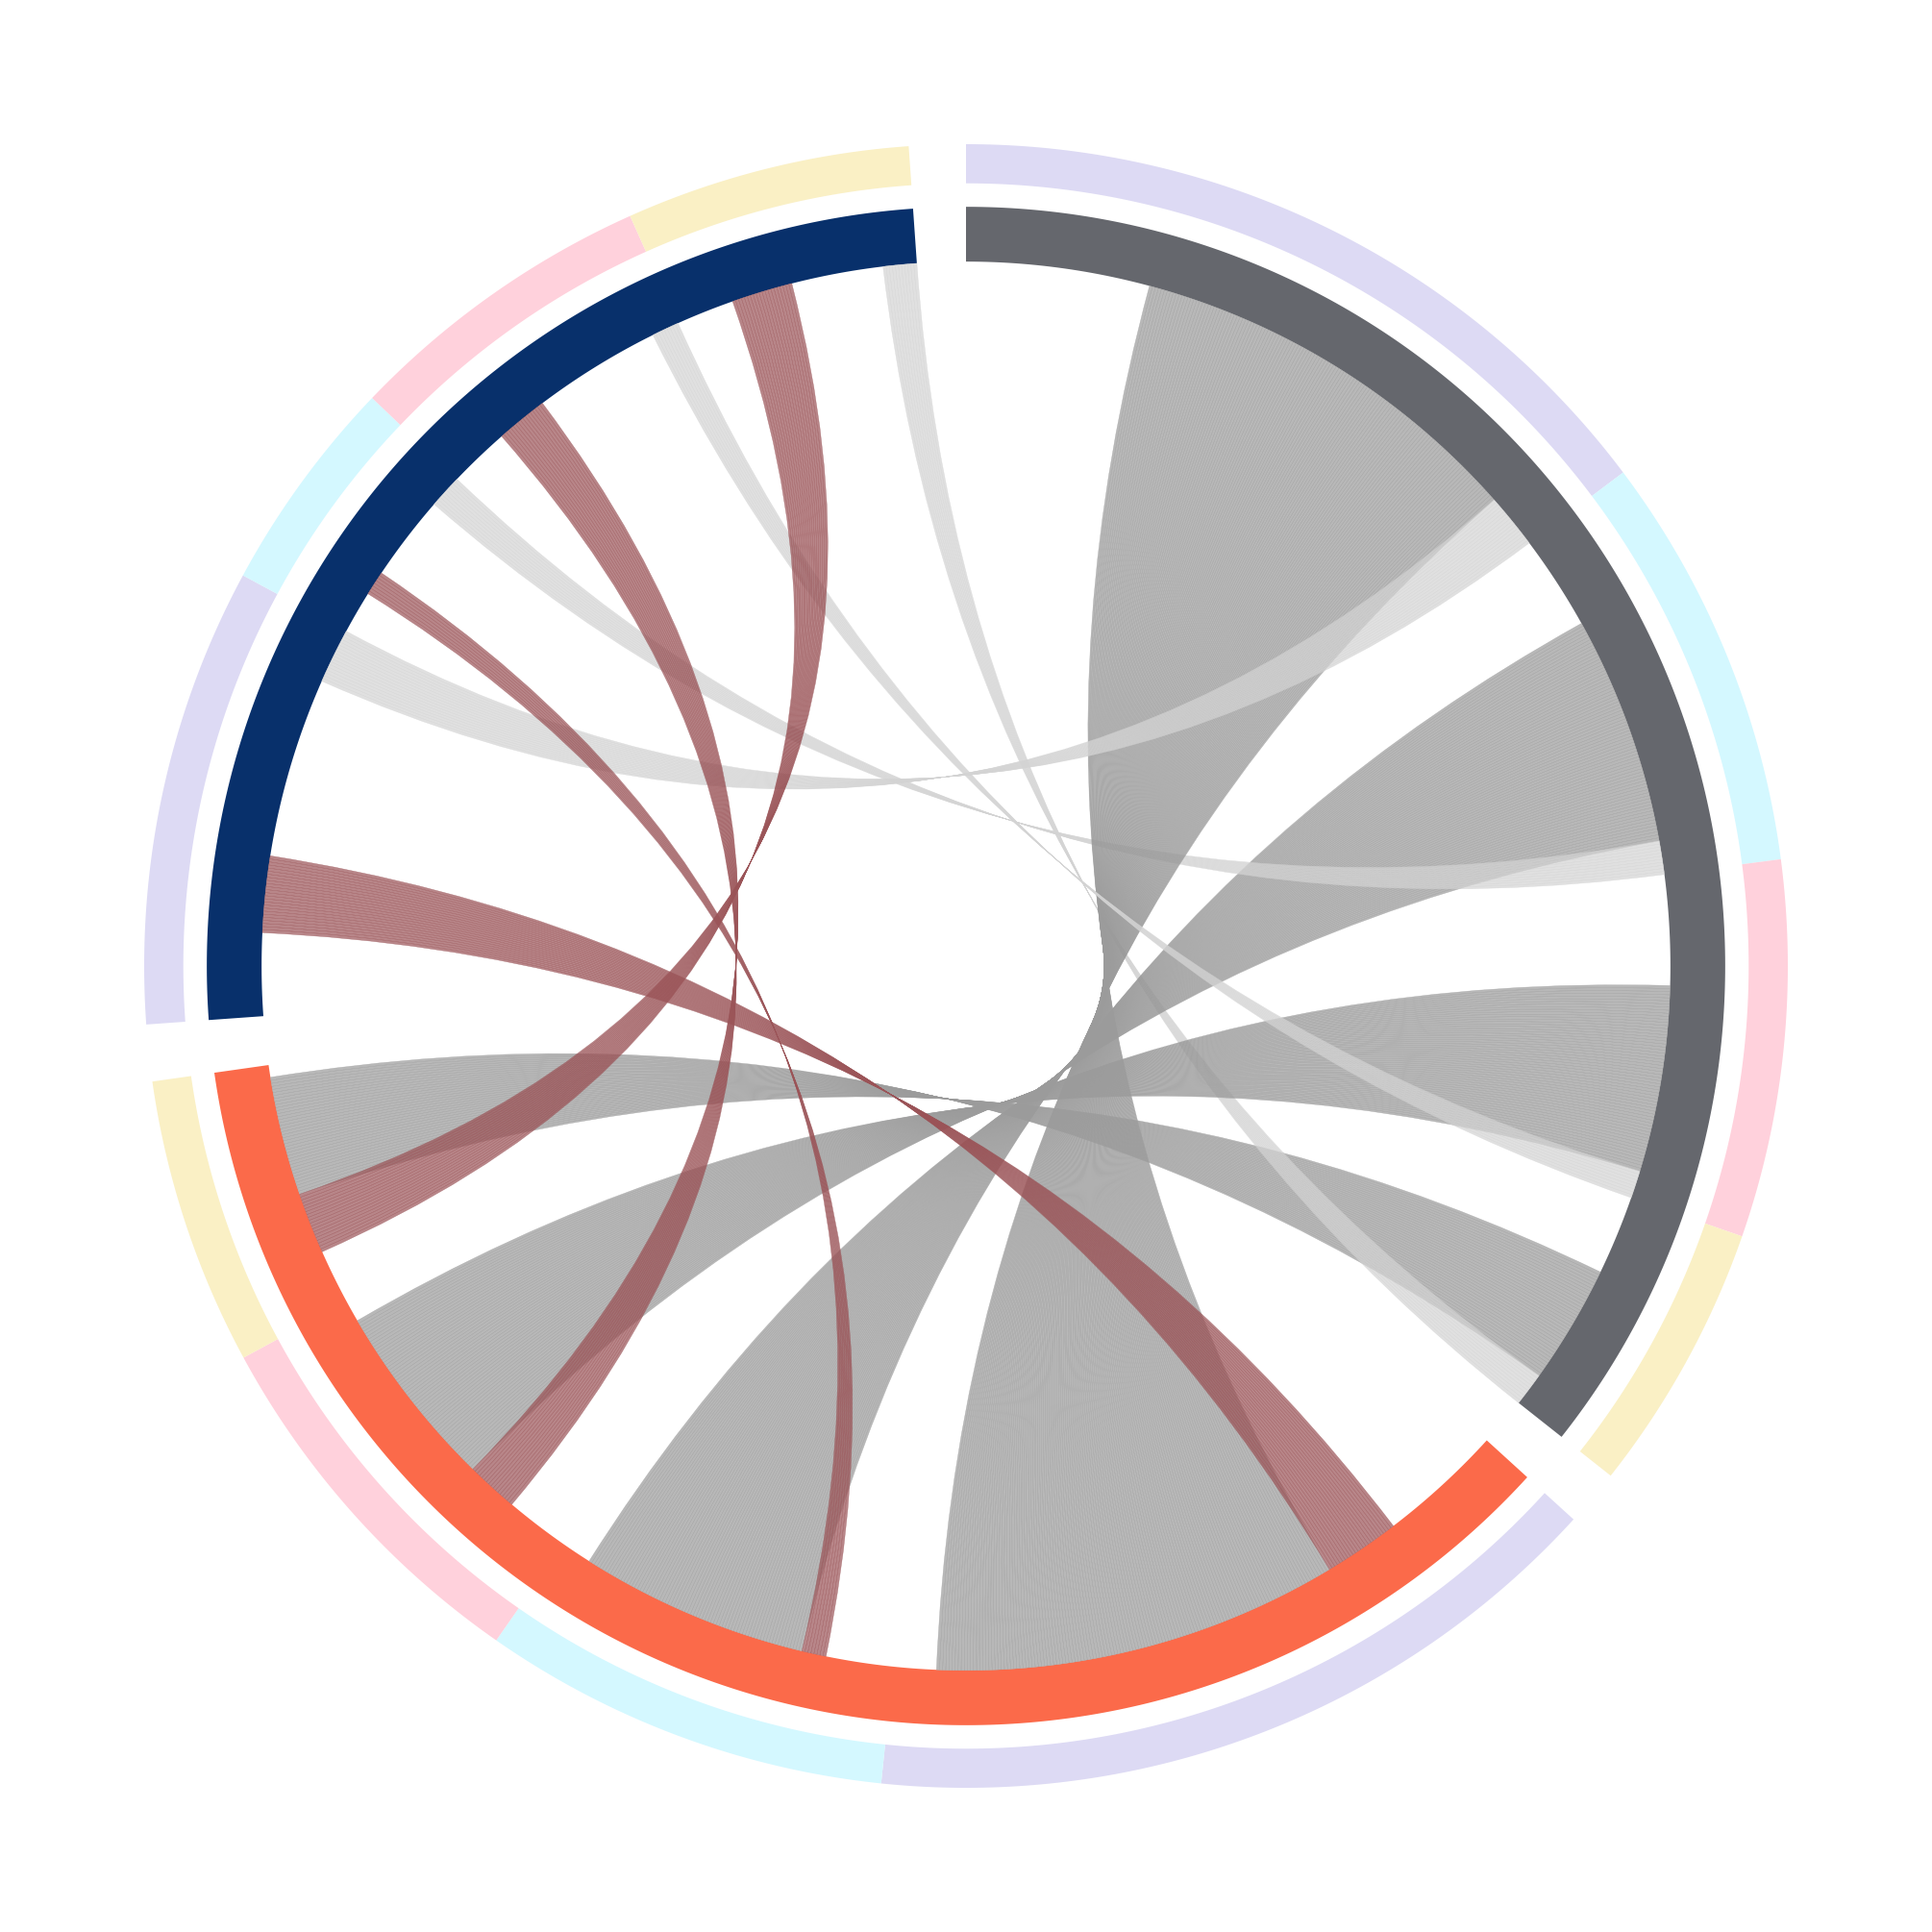

In [79]:
groups = ['initial', 'reprogram', 'target']
# name2color = {
#     'initial': "#4B4D51",     # dark gray
#     'reprogram': "#82B289",  # sage green
#     'target': "#517DAA",     # blue
# }
name2color = {
    'initial': "#65676D", #"#808080",     # gray
    'reprogram': "#FB6A4A",  # red
    'target': "#08306B",     # blue
}
group_links_colors = {
    ('initial', 'target'): '#D3D3D3',
    ('reprogram', 'target'): '#9A5357',#'#FB6A4A',
    ('initial', 'reprogram'): '#9B9B9B',
}
group_pairs = [('reprogram', 'target'), ('initial', 'reprogram'), ('initial', 'target')]

path2color = {
    'hsc_markers': '#FAF0C5',       # pale yellow
    'fib_markers': '#D4F8FF',       # pale blue
    'endo_markers': '#DDDAF4',      # pale purple
    'hsc_differentiation': '#FFD1DC', # pale pink
    # 'splicing': '#D4F6EA',           # pale aqua
    # 'hippo': '#FAE3E3',              # pale coral
}


isoform_pos = {}
sectors = {}
for group in groups:
    subs = (
        tmp_exploded[tmp_exploded[f"{group}_pct_top"].notnull()]
        .sort_values(by=["pathway", "sort_col", "gene_name"])
    )
    unique_isoforms = subs[f"{group}_pct_top"].tolist()
    isoform_pos[group] = {iso: i for i, iso in enumerate(unique_isoforms)}
    sectors[group] = len(unique_isoforms)

# --- Circos plot ---
plt.rcParams['figure.dpi'] = 300
circos = Circos(sectors, space=4)

for sector in circos.sectors:
    group = sector.name
    n_pos = sectors[group]
    if n_pos == 0:
        continue
        
    # Main colored arc
    arc_track = sector.add_track((90, 97))#((95, 100))
    arc_track.axis(fc=name2color[group], ec='none')
    
    
    pathway_track = sector.add_track((100, 105))
    subs = (
        tmp_exploded[tmp_exploded[f"{group}_pct_top"].notnull()]
        .sort_values(by=["pathway", "sort_col", "gene_name"])
    )
    pathway_by_pos = subs['pathway'].tolist()
    block_start = 0
    for i in range(1, n_pos + 1):
        if i == n_pos or pathway_by_pos[i] != pathway_by_pos[block_start]:
            pw = pathway_by_pos[block_start]
            color = path2color.get(pw, "white")
            pathway_track.rect(
                block_start, i,   # Only start, end positions!
                fc=color,
                ec='none'
            )
            block_start = i


isoform_pos_by_group_pathway = {group: defaultdict(dict) for group in groups}
for group in groups:
    subs = (
        tmp_exploded[tmp_exploded[f"{group}_pct_top"].notnull()]
        .sort_values(by=["pathway", "sort_col", "gene_name"])
    )
    for i, row in enumerate(subs.itertuples()):
        isoform = getattr(row, f"{group}_pct_top")
        pathway = row.pathway if pd.notnull(row.pathway) else "unknown"
        isoform_pos_by_group_pathway[group][pathway][isoform] = i

link_records = []
for pw in path2color.keys():
    for g1, g2 in group_pairs:
        pos_dict1 = isoform_pos_by_group_pathway[g1].get(pw, {})
        pos_dict2 = isoform_pos_by_group_pathway[g2].get(pw, {})
        shared_isoforms = set(pos_dict1.keys()).intersection(pos_dict2.keys())
        for iso in shared_isoforms:
            pos1 = pos_dict1[iso]
            pos2 = pos_dict2[iso]
            pairs = tuple(sorted([g1, g2]))
            priority = 2 if pairs == ('reprogram', 'target') else 1
            color = group_links_colors.get(pairs, 'gray')
            link_records.append({
                'g1': g1, 'pos1': pos1,
                'g2': g2, 'pos2': pos2,
                'color': color, 'priority': priority,
                'isoform': iso,
                'pathway': pw,
            })

link_records_sorted = sorted(link_records, key=lambda d: d['priority'])
for rec in link_records_sorted:
    circos.link(
        (rec['g1'], rec['pos1'], rec['pos1'] + 1),
        (rec['g2'], rec['pos2'], rec['pos2'] + 1),
        color=rec['color'], alpha=0.7,
    )


fig = circos.plotfig(dpi=300)
fig.set_size_inches(6, 6)

fig.patch.set_alpha(0)
for ax in fig.get_axes():
    ax.patch.set_alpha(0)

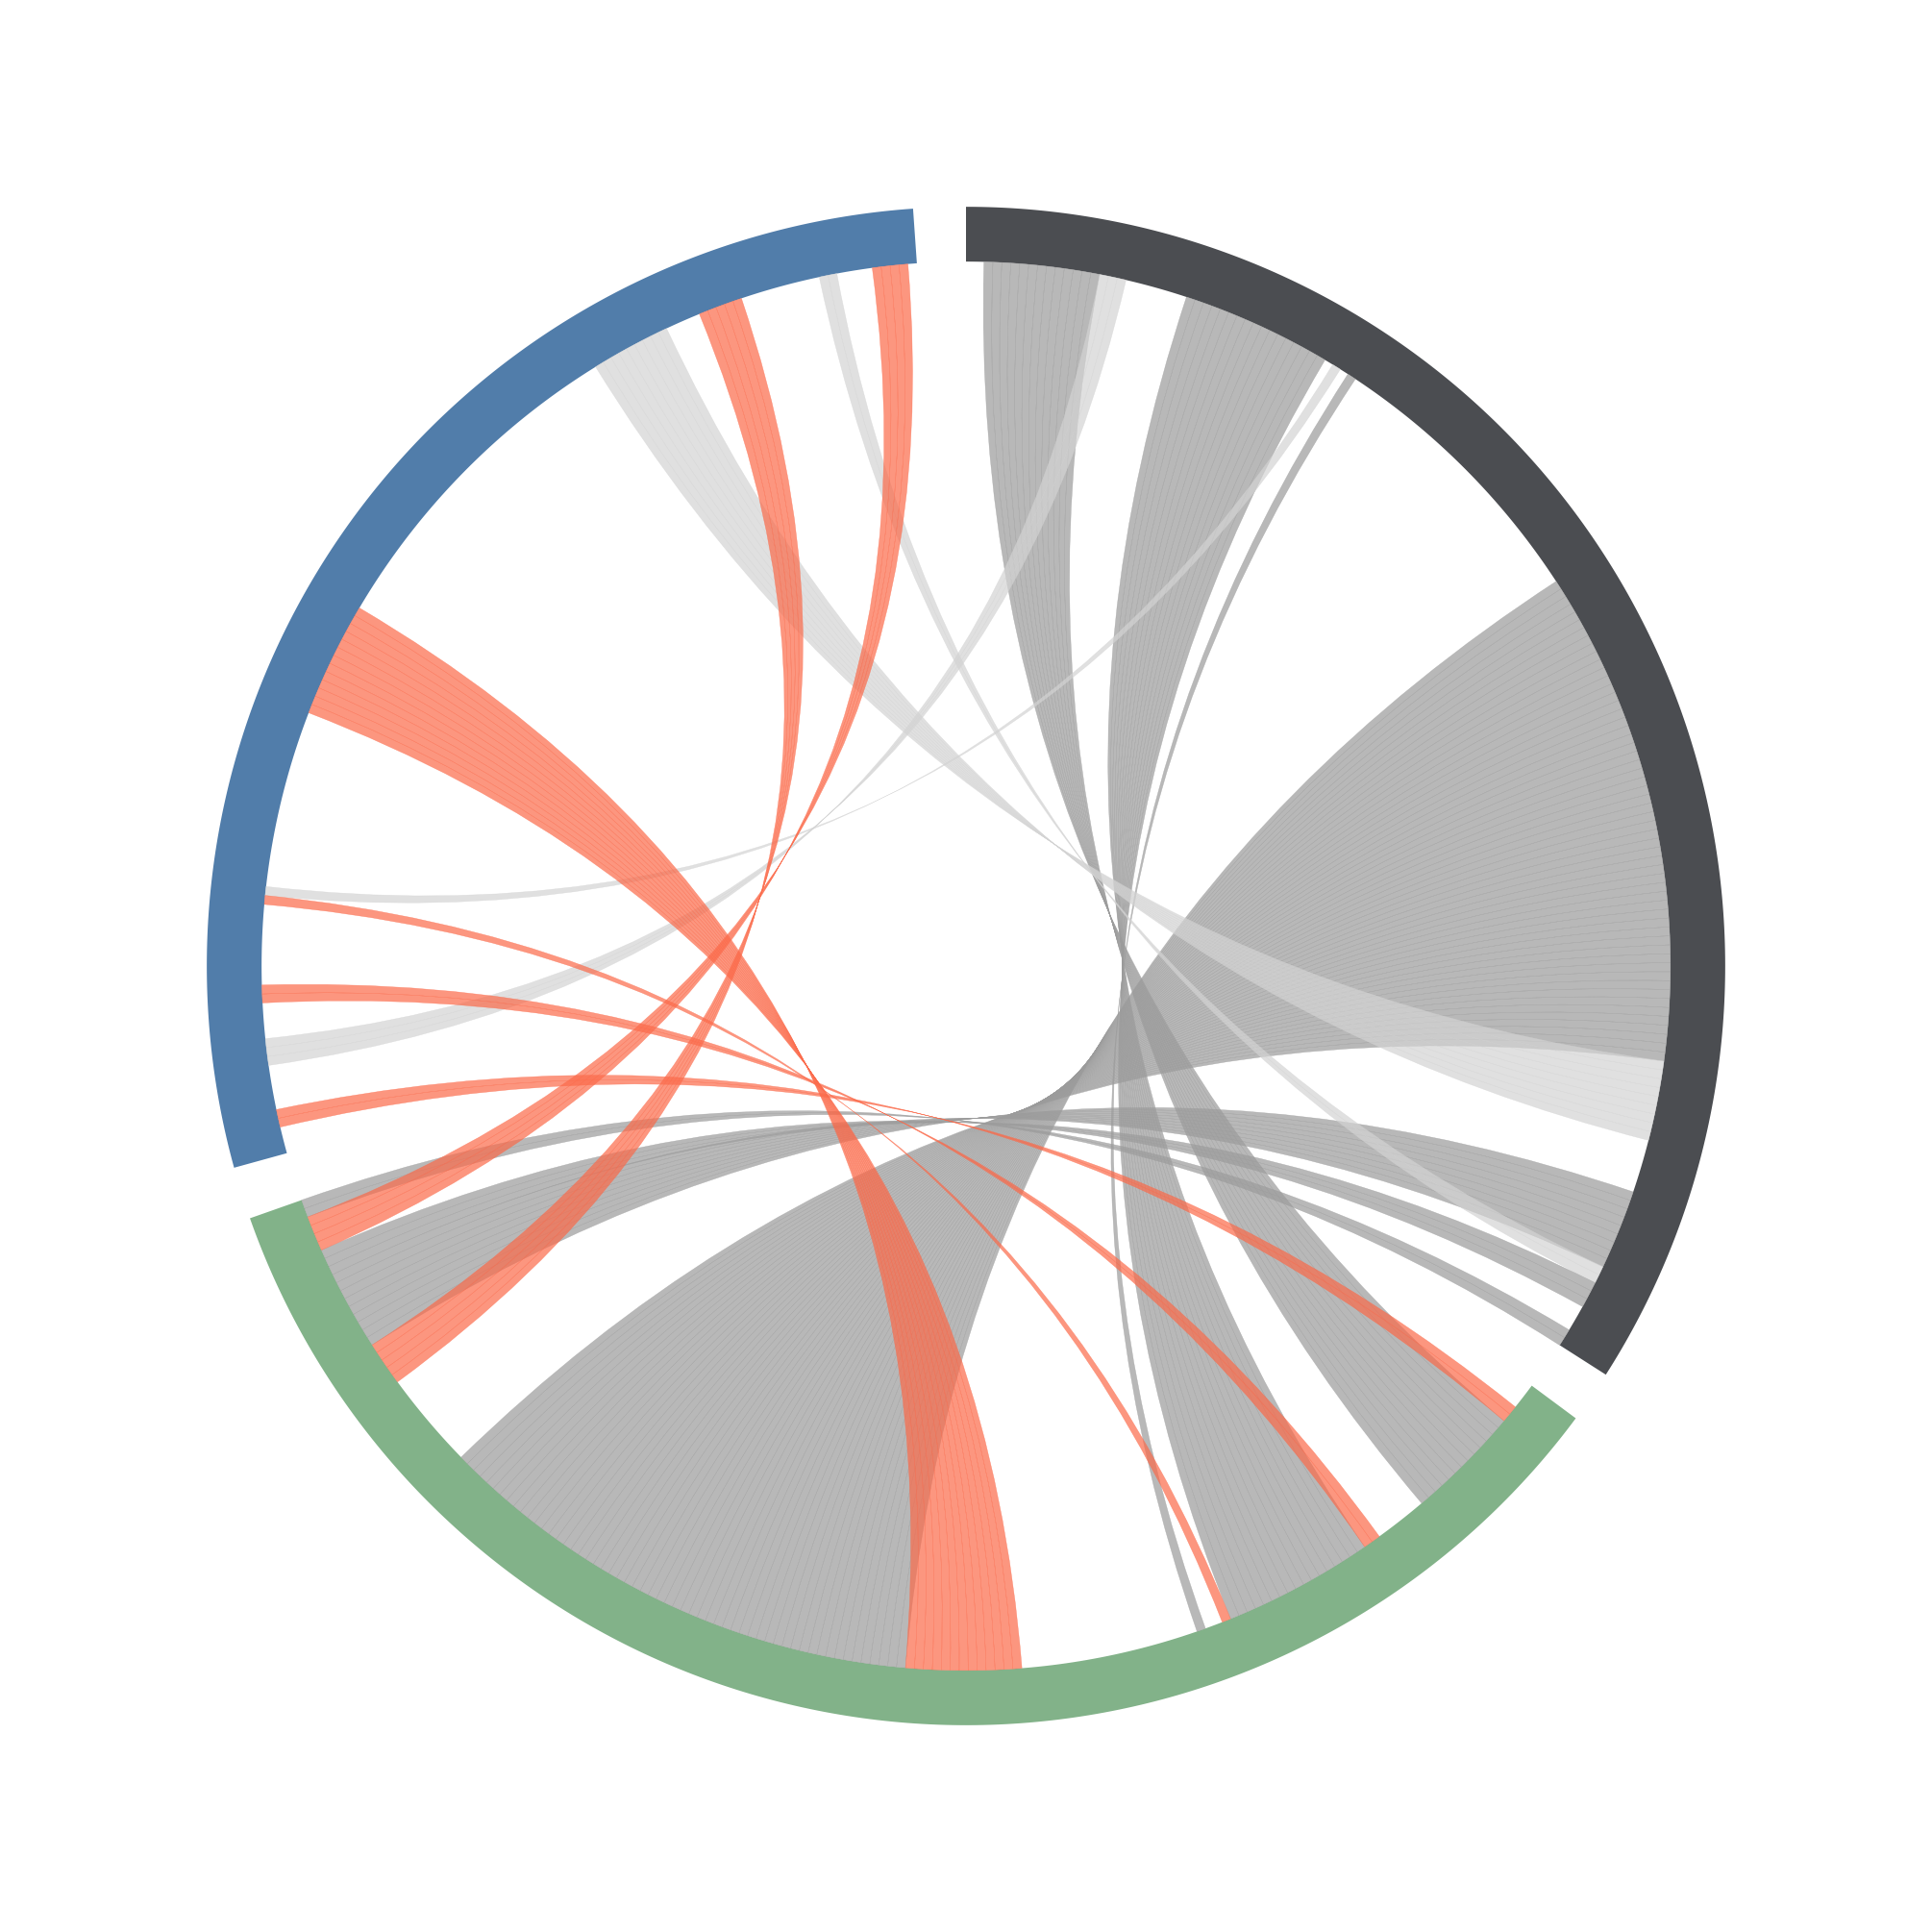

In [30]:
groups = ['initial', 'reprogram', 'target']
name2color = {
    'initial': "#4B4D51",     # dark gray
    'reprogram': "#82B289",  # sage green
    'target': "#517DAA",     # blue
}
group_links_colors = {
    ('initial', 'target'): '#D3D3D3',
    ('reprogram', 'target'): '#FB6A4A',
    ('initial', 'reprogram'): '#9B9B9B',
}
group_pairs = [('reprogram', 'target'), ('initial', 'reprogram'), ('initial', 'target')]


# path2color = {
#     'Endothelial': '#F6F4D6', # pale yellow
#     'Hippo': '#DFEDFA', # pale blue
#     'Notch/numb/acd': '#DDDAF4', # pale purple
# }



isoform_pos = {}
sectors = {}
for group in groups:
    subs = (
        tmp_exploded[tmp_exploded[f"{group}_pct_top"].notnull()]
        .sort_values(by=["pathway", "sort_col", "gene_name"])
    )
    unique_isoforms = subs[f"{group}_pct_top"].tolist()
    isoform_pos[group] = {iso: i for i, iso in enumerate(unique_isoforms)}
    sectors[group] = len(unique_isoforms)
    
# label_bg_colors = []
# for pos in range(n_pos):
#     label = str(pos2isoform[pos])
#     gene_row = tmp[
#         (tmp[f"{group}_pct_top"] == label) & (tmp['pathway'].notnull())
#     ]
#     if gene_row.shape[0]:
#         pathway = gene_row.iloc[0]["pathway"]
#         color = path2color.get(pathway, 'white')
#     else:
#         color = 'white'
#     label_bg_colors.append(color)



# --- Circos plot ---
plt.rcParams['figure.dpi'] = 300
circos = Circos(sectors, space=4)

for sector in circos.sectors:
    group = sector.name
    n_pos = sectors[group]
    if n_pos == 0:
        continue
        
    # Main colored arc
    arc_track = sector.add_track((90, 97))#((95, 100))
    arc_track.axis(fc=name2color[group], ec='none')
    
#     # Isoform labels
#     label_track = sector.add_track((98, 100))#((120, 125))
#     # label_track.axis(fc='none')
#     positions = [(pos + 0.5) for pos in range(n_pos)]
#     pos2isoform = {v: k for k, v in isoform_pos[group].items()}
#     labels = [str(pos2isoform[pos]) for pos in range(n_pos)]
    
#     label_track.xticks(
#         positions,
#         labels,
#         label_size=8,
#         label_orientation="vertical",
#         tick_length=0,
#         # text_kws={'backgroundcolor': 'red'}
#     )


# --- Build and draw links as before ---
link_records = []
for idx, row in tmp_exploded.iterrows():
    i_val = row['initial_pct_top']
    r_val = row['reprogram_pct_top']
    t_val = row['target_pct_top']
    # Skip link if all three are shared
    if pd.notnull(i_val) and pd.notnull(r_val) and pd.notnull(t_val) and (i_val == r_val == t_val):
        continue
    for g1, g2 in group_pairs:
        iso1 = row[f"{g1}_pct_top"]
        iso2 = row[f"{g2}_pct_top"]
        # Only draw links if isoforms are identical (i.e. shared) between two groups
        if pd.notnull(iso1) and pd.notnull(iso2) and iso1 == iso2:
            pos1 = isoform_pos[g1].get(iso1)
            pos2 = isoform_pos[g2].get(iso2)
            if pos1 is not None and pos2 is not None:
                pairs = tuple(sorted([g1, g2]))
                priority = 2 if pairs == ('reprogram', 'target') else 1
                color = group_links_colors.get(pairs, 'gray')
                link_records.append({
                    'g1': g1, 'pos1': pos1,
                    'g2': g2, 'pos2': pos2,
                    'color': color, 'priority': priority
                })

link_records_sorted = sorted(link_records, key=lambda d: d['priority'])
for rec in link_records_sorted:
    circos.link(
        (rec['g1'], rec['pos1'], rec['pos1'] + 1),
        (rec['g2'], rec['pos2'], rec['pos2'] + 1),
        color=rec['color'], alpha=0.7, #ec='white',
    )

fig = circos.plotfig(dpi=300)
fig.set_size_inches(6, 6)

fig.patch.set_alpha(0)
for ax in fig.get_axes():
    ax.patch.set_alpha(0)